In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import os
from pathlib import Path

In [3]:
os.chdir("..")
os.getcwd()

'/Users/ColdMuffin/Work/Practice/neuron-visualizer'

In [4]:
from src.dense_layer import DenseLayer
from src.activation import ReLU
from src.loss import SquaredError

In [5]:
network = [
  DenseLayer(1, 2),
  ReLU(),
  DenseLayer(2, 6),
  ReLU(),
  DenseLayer(6, 1),
  SquaredError()
]

In [6]:
def forward(x, y):
  y_pred = network[4].forward(
    network[3].forward(
      network[2].forward(
        network[1].forward(
          network[0].forward(
            x.reshape(SIZE, 1)
          )
        )
      )
    )
  )
  return y_pred, network[-1].forward(y.reshape(SIZE, 1), y_pred)

In [7]:
def loss(x, y):
  y_pred = forward(x)
  loss = network[-1](y, y_pred)
  return y_pred, loss

In [8]:
def backprop():
  grad = network[-1].backward()
  for i in range(len(network)-2, -1, -1):
    grad = network[i].backward(grad)

In [9]:
SIZE = 100
x = np.linspace(0, 2*np.pi, SIZE)
y = np.sin(x)
y += np.random.normal(0, .4, SIZE)

In [10]:
def train(x, y, epochs: int = 10):
  for i in range(epochs):
    forward(x, y)
    backprop()

In [21]:
y_pred, loss = forward(x, y)
print(loss)

20.107684391960195


In [20]:
train(x, y, 500)

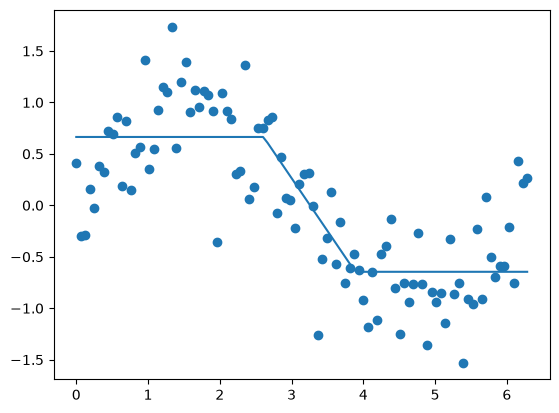

In [22]:
fig, ax = plt.subplots()
ax.scatter(x, y)
ax.plot(x, y_pred)